# 06 — InternVL3-2B Zero-shot (prompt v3): Inference Health and Hold-out Results

`OpenGVLab/InternVL3-2B` zero-shot inference, top-3 SVI per building, 3-field JSON-constrained prompt (v3, 2026-06-06). Per-image predictions are aggregated per `pand_id` via majority vote (`building_type`) and median (`construction_year`, `num_floors`); the TABULA period is derived from the median year via `tabula_matcher.classify_period` — the same year-to-period mapping applied to GT.

Prompt v3 removed the `construction_period` field (its boundary years anchored v2's year predictions onto 1975/1991/1992), removed `facade_material` (no GT), and replaced the AB-default rule with visible-cue type criteria. v2 artifacts are kept under `v2_holdout_*` as the prompt-ablation baseline.

Output schema is locked to match Notebook 05 (`T2_dinov2_holdout_headline`) so the two headline tables can be `pd.concat`-ed without column renaming.

### Verbatim prompt (from `src/stage1/vlm/internvl3_runner.py`)

```
Look at this Dutch residential building street-view photo. Estimate three physical attributes of the main building in view.

Respond with EXACTLY one JSON object, no markdown fences, no extra text. You MUST provide values for ALL fields. NEVER return null.

Required keys:

- "building_type": one of
    "SFH" = single-family house, FREE-STANDING: open space visible on at
            least one side. A building sharing BOTH side walls in a
            continuous row is NEVER SFH.
    "TH"  = terraced / row house: a dwelling in a continuous row of similar
            houses, typically 2-3 storeys, in a residential street
    "AB"  = apartment block: multiple dwellings stacked in one building.
            Cues: a shared entrance with many doorbells/mailboxes, external
            access galleries, a wide flat repetitive facade, OR a narrow
            historic building of 3+ storeys in a dense city-centre street
            (these are usually subdivided into stacked apartments)
    "MFH" = collective housing without self-contained dwellings (student
            dormitory, rooming house, elderly care home)
  If unsure between TH and AB: a 2-3 storey row house in a quiet residential
  street is TH; 4+ storeys, shops at ground level, or a dense city-centre
  street means AB.

- "construction_year": integer 1800-2025. Estimate from visible evidence:
  facade style, brickwork, window shapes, roof form, detailing.

- "num_floors": integer 1-30, visible storeys above ground (count window rows).

Your JSON object must contain ALL three keys, in this order. If uncertain,
give your best single estimate - never omit a key.

Example: {"building_type": "TH", "construction_year": 1932, "num_floors": 3}
```

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from _stage1_plot import (
    REPO, FIG_DIR, TABLE_DIR, REPORTS_DIR,
    setup_mpl, save_fig, save_table, confusion_heatmap,
    compute_locked_limits, provenance_table,
    TYPE_LABELS, CITY_LABELS, TYPE_PALETTE, CITY_PALETTE,
)

setup_mpl()
AXIS_LIMITS = compute_locked_limits()

VLM_DIR = REPORTS_DIR / 'vlm_internvl3'
per_image_path   = VLM_DIR / 'v3_holdout_per_image.parquet'
per_pand_path    = VLM_DIR / 'v3_holdout_per_pand_id.parquet'
ho_metrics_path  = VLM_DIR / 'v3_holdout_metrics.json'

per_image = pd.read_parquet(per_image_path)
per_pand  = pd.read_parquet(per_pand_path)
ho_metrics = json.loads(ho_metrics_path.read_text())

prov_df = provenance_table([per_image_path, per_pand_path, ho_metrics_path])
print('AXIS_LIMITS (shared with Notebook 05):', AXIS_LIMITS)
print(f'per_image n={len(per_image):,}  per_pand_id n={len(per_pand):,}')
prov_df

AXIS_LIMITS (shared with Notebook 05): {'year_scatter': (1850, 2030), 'year_mae_bar': (0.0, 53), 'floors_mae_bar': (0.0, 0.9), 'type_acc_bar': (0.0, 1.0)}
per_image n=5,261  per_pand_id n=2,018


,file,size_kb,mtime
0,reports\stage1\vlm_internvl3\v3_holdout_per_im...,313.0,2026-06-06 18:58
1,reports\stage1\vlm_internvl3\v3_holdout_per_pa...,35.3,2026-06-06 18:59
2,reports\stage1\vlm_internvl3\v3_holdout_metric...,2.8,2026-06-06 18:59


## 1. Inference health

In [2]:
n_image          = len(per_image)
parse_ok_pct     = per_image['parse_ok'].mean() * 100
inf_sec_median   = per_image['inference_sec'].median()
# v3 prompt has no period/material fields; year-period consistency is
# definitionally 100% (period derived from the year at aggregation)

health = pd.DataFrame([{
    'n_image':                n_image,
    'n_pand_id':              len(per_pand),
    'parse_ok_pct':           round(parse_ok_pct, 2),
    'inference_sec_median':   round(inf_sec_median, 3),
}])
save_table(health, 'T1_vlm_inference_health')
health.T

[tbl] reports\tables\stage1\T1_vlm_inference_health.csv  +  T1_vlm_inference_health.md


,0
n_image,5261.00
n_pand_id,2018.00
parse_ok_pct,99.96
inference_sec_median,2.95


## 2. Hold-out test results

In [3]:
n_dropped = int(per_pand['pred_type'].isna().sum())
print(f'per_pand_id n={len(per_pand):,}  evaluated n={ho_metrics["n_eval"]:,}  dropped (parse failed across all images)={n_dropped}')
# period_acc: year-derived (classify_period on pred/true year); not yet in
# the locked T2 schema until the DINOv2 backfill adds it on the 05 side too
print(f'period_acc = {ho_metrics["period_acc"]:.4f} (n={ho_metrics["period_n_eval"]:,}; v2 self-reported: 0.0492)')
ci = ho_metrics['bootstrap_95ci']

headline = pd.DataFrame([{
    'n_eval':              ho_metrics['n_eval'],
    'type_acc':            ho_metrics['type_acc'],
    'type_acc_lo':         ci['type_acc']['lo'],
    'type_acc_hi':         ci['type_acc']['hi'],
    'macro_f1':            ho_metrics['type_macro_f1'],
    'macro_f1_lo':         ci['type_macro_f1']['lo'],
    'macro_f1_hi':         ci['type_macro_f1']['hi'],
    'year_mae':            ho_metrics['year_mae'],
    'year_mae_lo':         ci['year_mae']['lo'],
    'year_mae_hi':         ci['year_mae']['hi'],
    'year_within_10y_pct': ho_metrics['year_within_10y_pct'],
    'floors_mae':          ho_metrics['floors_mae'],
    'floors_mae_lo':       ci['floors_mae']['lo'],
    'floors_mae_hi':       ci['floors_mae']['hi'],
    'floors_exact_pct':    ho_metrics['floors_exact_pct'],
}])
save_table(headline, 'T2_vlm_holdout_headline')
headline.T

per_pand_id n=2,018  evaluated n=2,016  dropped (parse failed across all images)=2
period_acc = 0.7688 (n=2,016; v2 self-reported: 0.0492)
[tbl] reports\tables\stage1\T2_vlm_holdout_headline.csv  +  T2_vlm_holdout_headline.md


,0
n_eval,2016.0000
type_acc,0.4945
type_acc_lo,0.4742
type_acc_hi,0.5154
macro_f1,0.2458
macro_f1_lo,0.2251
macro_f1_hi,0.2665
year_mae,30.6500
year_mae_lo,29.7038
year_mae_hi,31.5833


[fig] reports\figures\stage1\vlm\F1_vlm_holdout_type_year.png  +  F1_vlm_holdout_type_year.pdf


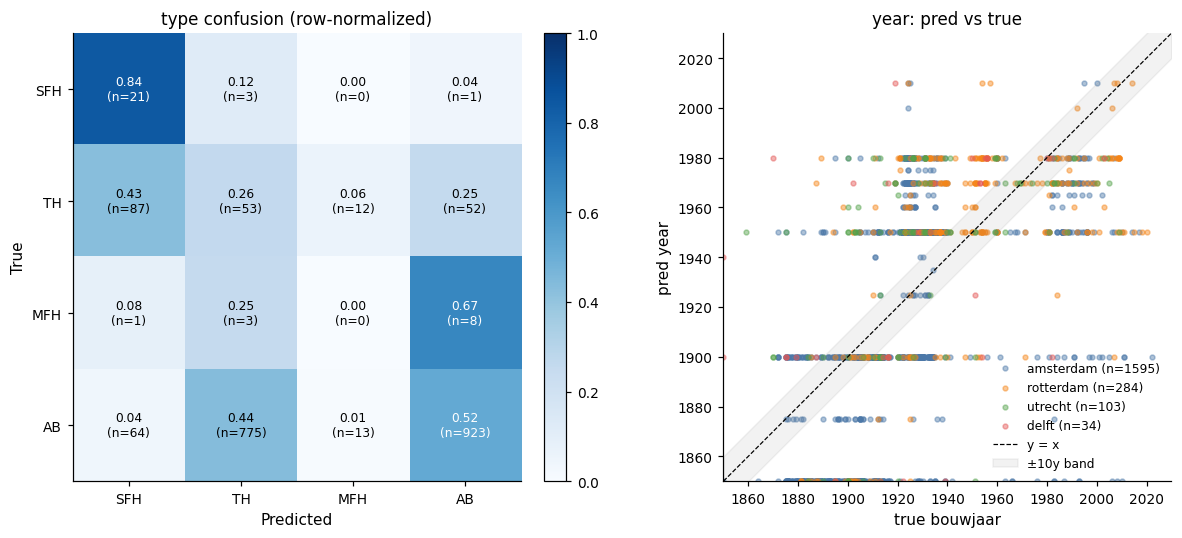

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = np.asarray(ho_metrics['type_confusion_matrix']['matrix'])
labels = ho_metrics['type_confusion_matrix']['labels']
confusion_heatmap(cm, labels, axes[0], title='type confusion (row-normalized)')

ax = axes[1]
# Aggregated per-building predictions vs GT
scored = per_pand.dropna(subset=['pred_year', 'true_bouwjaar'])
for city in CITY_LABELS:
    sub = scored[scored['city'] == city]
    ax.scatter(sub['true_bouwjaar'], sub['pred_year'],
               s=10, alpha=0.45, color=CITY_PALETTE[city], label=f'{city} (n={len(sub)})')
lo, hi = AXIS_LIMITS['year_scatter']
ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='y = x')
ax.fill_between([lo, hi], [lo - 10, hi - 10], [lo + 10, hi + 10],
                color='gray', alpha=0.10, label='±10y band')
ax.set_xlim(*AXIS_LIMITS['year_scatter']); ax.set_ylim(*AXIS_LIMITS['year_scatter'])
ax.set_xlabel('true bouwjaar'); ax.set_ylabel('pred year')
ax.set_title('year: pred vs true')
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
save_fig(fig, 'F1_vlm_holdout_type_year', 'vlm')
plt.show()

[fig] reports\figures\stage1\vlm\F2_vlm_per_class_per_city.png  +  F2_vlm_per_class_per_city.pdf


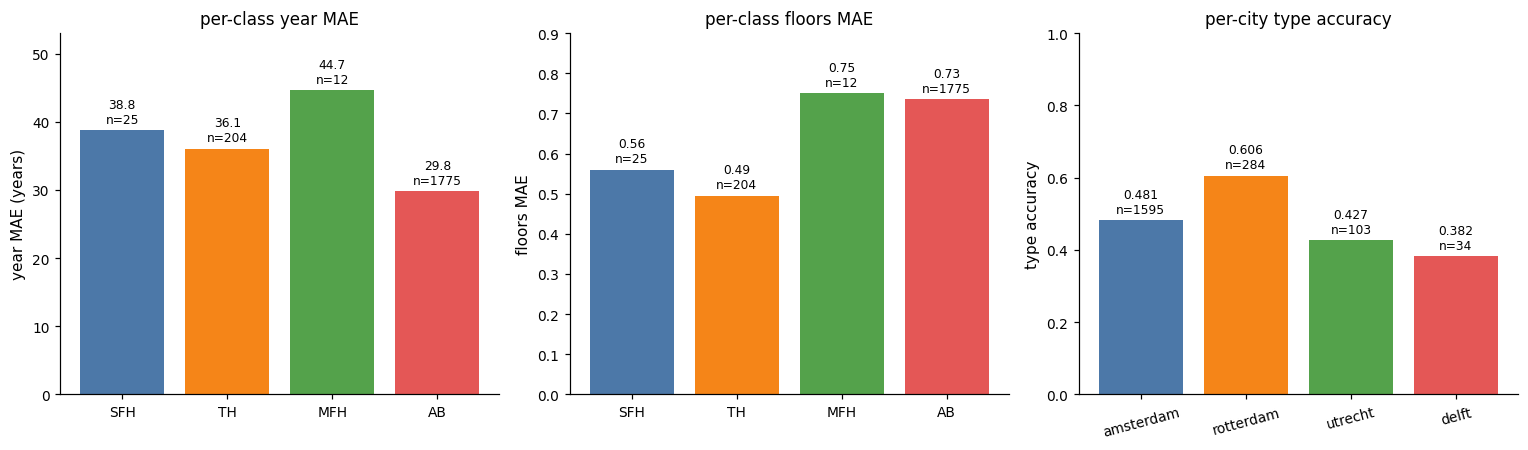

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

pc = ho_metrics['per_class_year_floors']
y_vals = [pc[t]['year_mae'] for t in TYPE_LABELS]
f_vals = [pc[t]['floors_mae'] for t in TYPE_LABELS]
n_per_class = [pc[t]['n'] for t in TYPE_LABELS]
axes[0].bar(TYPE_LABELS, y_vals, color=[TYPE_PALETTE[t] for t in TYPE_LABELS])
axes[0].set_ylim(*AXIS_LIMITS['year_mae_bar'])
axes[0].set_ylabel('year MAE (years)')
axes[0].set_title('per-class year MAE')
for i, (v, n) in enumerate(zip(y_vals, n_per_class)):
    axes[0].text(i, v + AXIS_LIMITS['year_mae_bar'][1]*0.02, f'{v:.1f}\nn={n}', ha='center', fontsize=8)

axes[1].bar(TYPE_LABELS, f_vals, color=[TYPE_PALETTE[t] for t in TYPE_LABELS])
axes[1].set_ylim(*AXIS_LIMITS['floors_mae_bar'])
axes[1].set_ylabel('floors MAE')
axes[1].set_title('per-class floors MAE')
for i, (v, n) in enumerate(zip(f_vals, n_per_class)):
    axes[1].text(i, v + AXIS_LIMITS['floors_mae_bar'][1]*0.02, f'{v:.2f}\nn={n}', ha='center', fontsize=8)

per_city = ho_metrics['per_city']
city_acc = [per_city[c]['type_acc'] for c in CITY_LABELS]
city_n   = [per_city[c]['n'] for c in CITY_LABELS]
axes[2].bar(CITY_LABELS, city_acc, color=[CITY_PALETTE[c] for c in CITY_LABELS])
axes[2].set_ylim(*AXIS_LIMITS['type_acc_bar'])
axes[2].set_ylabel('type accuracy')
axes[2].set_title('per-city type accuracy')
for i, (v, n) in enumerate(zip(city_acc, city_n)):
    axes[2].text(i, v + 0.02, f'{v:.3f}\nn={n}', ha='center', fontsize=8)
axes[2].tick_params(axis='x', rotation=15)

fig.tight_layout()
save_fig(fig, 'F2_vlm_per_class_per_city', 'vlm')
plt.show()